In [4]:
import os
import json
import yaml
from collections import defaultdict
from pathlib     import Path
from functools import partial
from tqdm import tqdm
from dataclasses import dataclass

import gtsam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import open3d as o3d

from moma_sg.data.arti4d import load_arti4d_ground_truth, InteractionSegment, Articulation
from moma_sg.articulation.point_estimator import InferencePointAxis
from moma_sg.utils.metrics import compute_articulation_delta_point_and_axis, compute_articulation_delta_twist, compute_twist_center
from typing import List, Tuple, Dict, Any


GT_DATA_ROOT = Path('../input_data/arti4d/raw')
GT_ARTICULATION, GT_OBJECT_TYPES, GT_OBJECT_DIFFICULTY = load_arti4d_ground_truth(GT_DATA_ROOT)


Listing all gt rooms, scenes, and segments...
Found 8 rooms:
  - din080
  - rh078
  - rh201
  - rr080
  - mhzh
  - imbit-exp
  - hsr
  - mhzh_exo

Scenes:
  - scene_2025-04-11-11-44-32
  - scene_2025-04-11-12-58-58
  - scene_2025-04-11-13-01-59
  - scene_2025-04-11-13-18-00
  - scene_2025-04-11-13-43-03
  - scene_2025-04-11-14-01-06
  - scene_2025-04-11-15-43-24
  - scene_2025-04-11-15-46-48
  - scene_2025-04-04-19-14-38
  - scene_2025-04-04-19-18-54
  - scene_2025-04-07-11-39-17
  - scene_2025-04-07-11-41-52
  - scene_2025-04-07-11-48-40
  - scene_2025-04-09-10-30-11
  - scene_2025-04-09-10-32-52
  - scene_2025-04-09-10-35-47
  - scene_2025-04-09-10-38-38
  - scene_2025-04-09-10-46-48
  - scene_2025-04-09-10-49-20
  - scene_2025-04-24-17-52-21
  - scene_2025-04-24-17-54-13
  - scene_2025-04-24-19-18-42
  - scene_2025-04-24-19-21-50
  - scene_2025-04-24-19-24-09
  - scene_2025-04-25-10-36-37
  - scene_2025-04-25-10-53-40
  - scene_2025-04-25-10-56-33
  - scene_2025-04-25-11-11-47
  - s

In [5]:
def compute_articulation_delta_twist(gt : Articulation, w_T_xi : np.ndarray, xi : np.ndarray, joint_type: str) -> np.ndarray[float, float]:
    """Computes the delta between a given articulation and a twist model consisting of
       world transform and twist vector. It extracts the rotation or translation axis 
       from the twist and the center of the rotation/a point on the translation.

       Returned errors are angular divergence of the main axis and positional divergence for the centers of rotations.

    Args:
        gt (Articulation): Articulation to compare against.
        w_T_xi (np.ndarray): World offset of the predicted articulation.
        xi (np.ndarray): Predicted articulation in the form of a twist.

    Returns:
        np.ndarray[float, float]: Axis divergens in rad, positional divergence in meters.
    """
    if joint_type.upper() == 'PRISMATIC':
        normalized_translation_direction = xi[3:] / np.linalg.norm(xi[3:])

        return compute_articulation_delta_point_and_axis(gt, w_T_xi[:3, 3], w_T_xi[:3, :3] @ normalized_translation_direction)
    elif joint_type.upper() == 'REVOLUTE':
        normalized_rotation_axis = xi[:3] / np.linalg.norm(xi[:3])
        w_P_rotation_origin  = compute_twist_center(w_T_xi, xi)
        w_V_rotation         = w_T_xi[:3, :3] @ normalized_rotation_axis
        return compute_articulation_delta_point_and_axis(gt, w_P_rotation_origin, w_V_rotation)
    else:
        raise ValueError(f'Unknown articulation type: "{gt.type}"')


def compute_articulation_delta_point_and_axis(gt : Articulation, w_P_center : np.ndarray, w_V_axis : np.ndarray, ) -> np.ndarray[float, float]:
    """Computes the delta between a given articulation and a predicted model consisting of a supporting point and 
       an axis. The type of error is computed based on the ground-thruth's articulation type.

       Eeturned errors are angular divergence of the main axis and positional divergence for the centers of rotations.

    Args:
        gt (Articulation): Articulation to compare against.
        w_P_center (np.ndarray): Supporting point of articulation in world frame.
        w_V_axis (np.ndarray): Axis of articulation in world frame.

    Returns:
        np.ndarray[float, float]: Axis divergence in rad, positional divergence in meters.
    """
    gt.axis = np.array(gt.axis)
    gt.position = np.array(gt.position)
    w_P_center = np.array(w_P_center)
    w_V_axis = np.array(w_V_axis) / np.linalg.norm(w_V_axis)

    if gt.type == 'PRISMATIC':
        # Amount of rotation per translation. Should be 0
        return np.array([np.arccos(np.clip(np.abs(w_V_axis @ gt.axis), 0, 1)), 0])
    elif gt.type == 'REVOLUTE':
        axis_cos = np.clip(np.abs(w_V_axis.T @ gt.axis), 0, 1)
        v_cross_v = np.cross(w_V_axis, gt.axis)
        # If lines are not parallel, calculate their distance
        if (vv_norm:=np.linalg.norm(v_cross_v)) >= 1e-4:
            articulation_distance = np.abs(((w_P_center - gt.position) * v_cross_v).sum()) / vv_norm
        else:
            articulation_distance = np.linalg.norm(np.cross(w_P_center - gt.position, gt.axis))
        return np.array([np.arccos(axis_cos), articulation_distance])
    else:
        raise ValueError(f'Unknown articulation type: "{gt.type}"')
    

def compute_mode_metrics(pred: InferencePointAxis) -> float:
    """Computes the error metrics for a given predicted articulation mode and a ground-truth articulation.

    Args:
        pred (InferencePointAxis): Predicted articulation mode.
        gt (Articulation): Ground-truth articulation.

    Returns:
        Dict[str, float]: Dictionary containing the computed metrics.
    """
    if pred.motion_type.lower() == 'opening-closing':
        return 1.0
    else:
        return 0.0

In [6]:
from moma_sg.articulation.point_estimator import _skew
def _compute_linear_motion(twist: np.ndarray, xs: np.ndarray) -> np.ndarray:
    """Computes the unit norm linear motion Ad(twist)_v at x."""
    if isinstance(twist, list):
        twist = np.array(twist)
    v = twist[3:][None, :]
    w_x = _skew(twist[:3])

    linear_motion = v - xs @ w_x
    linear_motion /= np.linalg.norm(linear_motion, axis=-1)[..., None]
    return linear_motion


def _compute_linear_motion_similarity(
    gt_twist: np.ndarray, pred_twist: np.ndarray, grasp_points: np.ndarray
) -> np.ndarray:
    """Computes the dot product between the ground truth and predicted
    linear motions at x."""
    gt_linear_motion = _compute_linear_motion(gt_twist, grasp_points)
    pred_linear_motion = _compute_linear_motion(pred_twist, grasp_points)

    return (gt_linear_motion * pred_linear_motion).sum(axis=-1)

def compute_twist_metrics(
    gt_articulation: np.ndarray,
    pred_articulation   : np.ndarray,
    initial_points     : np.ndarray,
) -> Tuple[float, float]:
    """Computes the average linear motion similarity and angle error along the
    path traced out by the given ground truth poses."""
    # Format input data.
    gt_twist = gt_articulation.twist
    pred_twist = pred_articulation.twist

    # Compute the linear motion dot products along the grasp path.
    similarities = _compute_linear_motion_similarity(gt_twist, pred_twist, initial_points)
    if (similarities < 0).sum() >= len(similarities) / 2:
        similarities *= -1

    # Compute the angle errors along the grasp path.
    angle_errors = np.arccos(np.clip(similarities, -1, 1))

    # Integrate along the grasp path.
    similarity = np.clip(similarities.mean(), -1, 1)
    angle_error = angle_errors.mean()

    # assert similarity >= 0
    # assert angle_error >= 0
    if similarity < 0:
        print(f"{similarity = } < 0 encoutered!")
    if angle_error < 0:
        print(f"{angle_error = } < 0 encoutered!")

    return similarity, angle_error

In [ ]:
## Load Moma-SG, Pandora, ArtiPoint results here
METHOD_PATHS = {
    "momasg": Path('/path/to/output_momasg/arti4d/'),
}

METHOD_SUBPATHS = {
    "momasg": 'articulation/',
}
CONSIDERED_SPLITS = ['rh201', 'rr080', 'din080', 'rh078']

INFERENCES = {}
RESULTS = {}

##### FOR ARTIPOINT ONLY #####
from ripl_articulation import solve_articulation_from_poses
def max_removed_pose(w_Ts_poses : np.ndarray) -> np.ndarray:
    w_Ps_positions = w_Ts_poses[:, :3, 3]
    deltas = np.linalg.norm(w_Ps_positions - w_Ps_positions[0], axis=-1)
    return w_Ts_poses[np.argmax(deltas)]


for room in GT_ARTICULATION.keys():
    if room not in CONSIDERED_SPLITS:
        continue
    if room not in INFERENCES:
        INFERENCES[room] = {}
    if room not in RESULTS:
        RESULTS[room] = {}
    for scene in GT_ARTICULATION[room].keys():
        if scene not in INFERENCES[room]:
            INFERENCES[room][scene] = {}
        if scene not in RESULTS[room]:
            RESULTS[room][scene] = {}
        print(f'Processing room {room}, scene {scene}')

        for method, method_path in METHOD_PATHS.items():
            if method not in INFERENCES[room][scene]:
                INFERENCES[room][scene][method] = {}
            if method not in RESULTS[room][scene]:
                RESULTS[room][scene][method] = {}

            if method in ['momasg', 'pandora']:
                scene_articulations_dir = method_path / room / scene / 'articulation'
                if not scene_articulations_dir.exists():    
                    print(f"Scene articulation directory does not exist: {scene_articulations_dir}")
                    continue
                model_files = [f for f in os.listdir(scene_articulations_dir) if f.endswith("_model.json")]
            elif method == 'artipoint':
                scene_articulations_dir = method_path / room / scene / 'results'
                segment_folders = [f for f in os.listdir(scene_articulations_dir) if f.startswith("segment_")]
            elif method == 'sturm':
                scene_articulations_dir = method_path / room / scene 
                segment_files = [f for f in os.listdir(scene_articulations_dir) if f.endswith(".json")]
            elif method == 'artgs':
                scene_articulations_dir = method_path / room / scene
                segment_folders = [f for f in os.listdir(scene_articulations_dir) if f.startswith("segment_")]
            elif method == 'ditto':
                scene_articulations_dir = method_path / room / scene / 'articulation_models'
                model_files = [f for f in os.listdir(scene_articulations_dir) if f.endswith(".json")]
            else:
                raise ValueError(f'Unknown method: "{method}"')
            
            if method in ['momasg', 'pandora']:
                for model_file in model_files:
                    model = InferencePointAxis.load(os.path.join(scene_articulations_dir, model_file))
                    INFERENCES[room][scene][method][(model.start_idx, model.end_idx)] = model
            elif method == 'artipoint':
                for _, segment_folder in enumerate(segment_folders):
                    segment_folder_path = scene_articulations_dir / segment_folder
                    # load metadata
                    with open(segment_folder_path / 'metadata.json', 'r') as f:
                        metadata = json.load(f)
                    start_idx, end_idx, id = int(metadata['start_frame']), int(metadata['end_frame']), int(metadata['id'])
                    
                    poses = np.load(segment_folder_path / 'poses.npy')

                    try:
                        w_T_b_prior = max_removed_pose(poses)
                        a_T_b_prior = gtsam.Pose3.Logmap(gtsam.Pose3(np.linalg.inv(poses[0]) @ w_T_b_prior))
                        xi, thetas = solve_articulation_from_poses(np.array([poses[0]] * len(poses)), poses, prior_xi=a_T_b_prior)
                        # xi, thetas = solve_articulation_from_poses(np.array([poses[0]] * len(poses)), poses, prior_xi=None)
                        w_T_xi = poses[0]
                    except:
                        print(f'Optimization failed for /{room}/{scene}/{seg_idx} with method {method}')
                        INFERENCES[room][scene][method][(start_idx, segment[1])] = InferencePointAxis(
                            position=None,
                            axis=None,
                            type=None,
                            start_idx=start_idx,
                            end_idx=end_idx,
                            id=id,
                            success=False
                        )
                        continue

                    axis = xi[:3] if np.linalg.norm(xi[:3]) > np.linalg.norm(xi[3:]) else xi[3:]
                    axis = w_T_xi[:3, :3] @ axis

                    INFERENCES[room][scene][method][(start_idx, end_idx)] = InferencePointAxis(
                        twist=xi,
                        w_T_a=w_T_xi,
                        position=compute_twist_center(w_T_xi, xi),
                        axis=axis,
                        type='revolute' if np.linalg.norm(xi[:3]) > np.linalg.norm(xi[3:]) else 'prismatic',
                        start_idx=start_idx,
                        end_idx=end_idx,
                        id=id,
                        success=True
                    )
            elif method == 'sturm':
                for _, segment_file in enumerate(segment_files):
                    segment_file_path = scene_articulations_dir / segment_file
                    with open(segment_file_path, 'r') as f:
                        model = json.load(f)
                    
                    # # transform rotation/translation back to world frame using first pose
                    first_pose = np.array(model['first_pose'])
                    first_pose_inv = np.linalg.inv(first_pose)

                    print(model["base_transform"])
                    base_transform = np.array(model["base_transform"]).reshape(4,4)
                    base_transform_inv = np.linalg.inv(base_transform)

                    # model["twist"] = base_transform @ np.array(model["twist"])
                    if model['joint_type'] == 'revolute':
                        axis = np.asarray(model['rotation_axis']) / np.linalg.norm(np.asarray(model['rotation_axis']))  
                        axis = first_pose[:3, :3] @ base_transform_inv[:3, :3] @ axis
                        position = model['rotation_center']
                        position = first_pose @ base_transform_inv @ np.hstack((np.asarray(model['rotation_center']), 1))
                        position = position[:3]
                    else:
                        axis = np.asarray(model['translation_axis']) / np.linalg.norm(np.asarray(model['translation_axis']))
                        axis = first_pose[:3, :3] @ base_transform[:3, :3] @ axis
                        position = first_pose @ base_transform_inv @ np.hstack((np.asarray(model['object_center']), 1))
                        position = position[:3]
                        position = model['object_center']
                    print(axis)
                    
                    INFERENCES[room][scene][method][(model["start_frame"], model["end_frame"])] = InferencePointAxis(
                        twist=np.array(model["twist"]),
                        w_T_a=np.array(model["first_pose"]),
                        position=position,
                        axis=axis,
                        type=model["joint_type"].upper(),
                        start_idx=model["start_frame"],
                        end_idx=model["end_frame"],
                        id=model["id"],
                        success=True
                    )

            elif method == 'ditto':
                raise NotImplementedError("Ditto evaluation not implemented yet.")
            
            elif method == 'artgs':
                for seg_idx, segment in enumerate(GT_ARTICULATION[room][scene]):
                    segment_folder = scene_articulations_dir / f'segment_{seg_idx}'
                    path = segment_folder / 'artgs' / 'train' / 'ours_best' / 'joint_info.json'
                    segment_idx = int(segment_folder.stem.split('_')[1])
                    
                    if not path.exists():
                        print(f"Path does not exist: {path}")
                        INFERENCES[room][scene][method][(segment[0], segment[1])] = InferencePointAxis(
                            id=seg_idx,
                            start_idx=segment[0],
                            end_idx=segment[1],
                            success=False
                        )
                        continue
                    
                    # Load joint prediction
                    with open(path, 'r') as f:
                        joint_data = json.load(f)
                        
                        # Find the joint with articulation data (not the root)
                        articulation_joint = None
                        for joint in joint_data:
                            if joint.get('joint') in ['slider', 'revolute', 'hinge'] and 'jointData' in joint:
                                articulation_joint = joint
                                break
                        
                        if articulation_joint is None:
                            print(f"No articulation joint found in {path}")
                            INFERENCES[room][scene][method][(segment[0], segment[1])] = InferencePointAxis(id=seg_idx, start_idx=segment[0], end_idx=segment[1], success=False)
                            continue
                        
                        # Extract axis direction
                        axis_direction = np.array(articulation_joint['jointData']['axis']['direction'])
                        normalized_axis = axis_direction / np.linalg.norm(axis_direction)
                        
                        # Load center point from PLY file
                        ply_path = path.parent / 'meshes' / 'axis_0_p.ply'
                        if ply_path.exists():
                            try:
                                point_cloud = o3d.io.read_point_cloud(str(ply_path))
                                center = np.asarray(point_cloud.points).mean(axis=0)
                            except:
                                print(f"Failed to load PLY file: {ply_path}")
                                center = np.array(articulation_joint['jointData']['axis']['origin'])
                        else:
                            center = np.array(articulation_joint['jointData']['axis']['origin'])
                        
                        # Determine joint type
                        joint_type = 'revolute' if articulation_joint['joint'] == 'revolute' else 'prismatic'

                        # Store prediction
                        INFERENCES[room][scene][method][(segment[0], segment[1])] = InferencePointAxis(
                            position=center,
                            axis=normalized_axis,
                            type=joint_type,
                            id=seg_idx,
                            start_idx=segment[0],
                            end_idx=segment[1],
                            success=True
                        )
                        print("success")

            for segment in GT_ARTICULATION[room][scene].keys():
                if segment in INFERENCES[room][scene][method]:
                    gt_articulation = GT_ARTICULATION[room][scene][segment]
                    pred_articulation = INFERENCES[room][scene][method][segment]
                    if pred_articulation.success:
                        if method in ['momasg']:
                            axis_metrics = compute_articulation_delta_point_and_axis(gt_articulation, pred_articulation.position, pred_articulation.axis)
                            twist_metrics = compute_twist_metrics(gt_articulation, pred_articulation, np.array([pred_articulation.position]))
                            mode_metric = compute_mode_metrics(pred_articulation)
                        elif method in ['artgs', "pandora"]:
                            
                            axis_metrics = compute_articulation_delta_point_and_axis(gt_articulation, pred_articulation.position, pred_articulation.axis)
                            twist_metrics = 0, 0 # No twist metrics for these methods
                            mode_metric = 0 # No mode metrics for these methods
                        elif method in ['artipoint', 'sturm']:
                            w_T_xi = pred_articulation.w_T_a
                            xi = pred_articulation.twist
                            initial_points = w_T_xi[:3, 3].reshape(1, 3)
                            axis_metrics = compute_articulation_delta_point_and_axis(gt_articulation, pred_articulation.position, pred_articulation.axis)
                            # axis_metrics = compute_articulation_delta_twist(gt_articulation, w_T_xi, xi, pred_articulation.type)
                            twist_metrics = compute_twist_metrics(gt_articulation, pred_articulation, initial_points)
                            mode_metric = 0
                        RESULTS[room][scene][method][segment] = {
                            'gt_joint_type': gt_articulation.type,
                            'gt_difficulty': gt_articulation.difficulty,
                            'pred_joint_type': pred_articulation.type,
                            'axis_error': axis_metrics[0],
                            'pos_error': axis_metrics[1],
                            'success': pred_articulation.success,
                            'tang_sim': twist_metrics[0],
                            'mode_acc': mode_metric
                        }
                    else:
                        print(f'  [{method}]  Warning: Articulation inference for segment {segment} in {room}/{scene} using {method} was not successful.')
        

Processing room rr080, scene scene_2025-04-22-11-48-01
Processing room rr080, scene scene_2025-04-17-15-33-44
Processing room rr080, scene scene_2025-04-17-15-25-14
Processing room rr080, scene scene_2025-04-22-09-58-49
Processing room rr080, scene scene_2025-04-22-11-50-40
Processing room rr080, scene scene_2025-04-22-09-56-24
Processing room rr080, scene scene_2025-04-10-16-05-09
Processing room rr080, scene scene_2025-04-10-13-11-16
Processing room rr080, scene scene_2025-04-22-09-53-49
Processing room rr080, scene scene_2025-04-22-11-45-15
Processing room din080, scene scene_2025-04-11-11-44-32
Processing room din080, scene scene_2025-04-11-12-58-58
  [momasg]  Warning: Articulation inference for segment (1882, 1951) in din080/scene_2025-04-11-12-58-58 using momasg was not successful.
Processing room din080, scene scene_2025-04-11-13-01-59
  [momasg]  Warning: Articulation inference for segment (1116, 1181) in din080/scene_2025-04-11-13-01-59 using momasg was not successful.
Proces

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

evaluated_method = 'momasg'

# Analyze results by joint type
all_segments = []
for room, room_data in RESULTS.items():
    if room not in CONSIDERED_SPLITS:
        continue
    for scene, scene_data in room_data.items():
        parsed_data = scene_data[evaluated_method]
        for seg, seg_data in parsed_data.items():
            seg_data['room'] = room
            seg_data['scene'] = scene
            seg_data['segment'] = seg
            all_segments.append(seg_data)


Total segments evaluated: 384
Articulation Estimation Results by Joint Type:


,count,avg_axis_error_deg,median_axis_error_deg,std_axis_error_deg,p50_axis_error_deg,p75_axis_error_deg,p90_axis_error_deg,avg_position_error_m,median_position_error_m,std_position_error_m,p50_position_error_m,p75_position_error_m,p90_position_error_m,type_accuracy,tang_sim_avg,mode_acc_avg
PRISMATIC,254,10.374,2.561,24.109,2.561,3.990,13.433,0.000,0.000,0.000,0.000,0.000,0.000,0.878,0.914,0.642
REVOLUTE,130,13.662,5.031,21.198,5.031,11.194,46.230,0.110,0.033,0.245,0.033,0.068,0.313,0.969,0.134,0.792
OVERALL,384,11.487,3.072,23.189,3.072,5.522,43.802,0.037,0.000,0.152,0.000,0.017,0.061,0.909,0.650,0.693
FAILED (pos_err > 2.5m) 0.0%,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


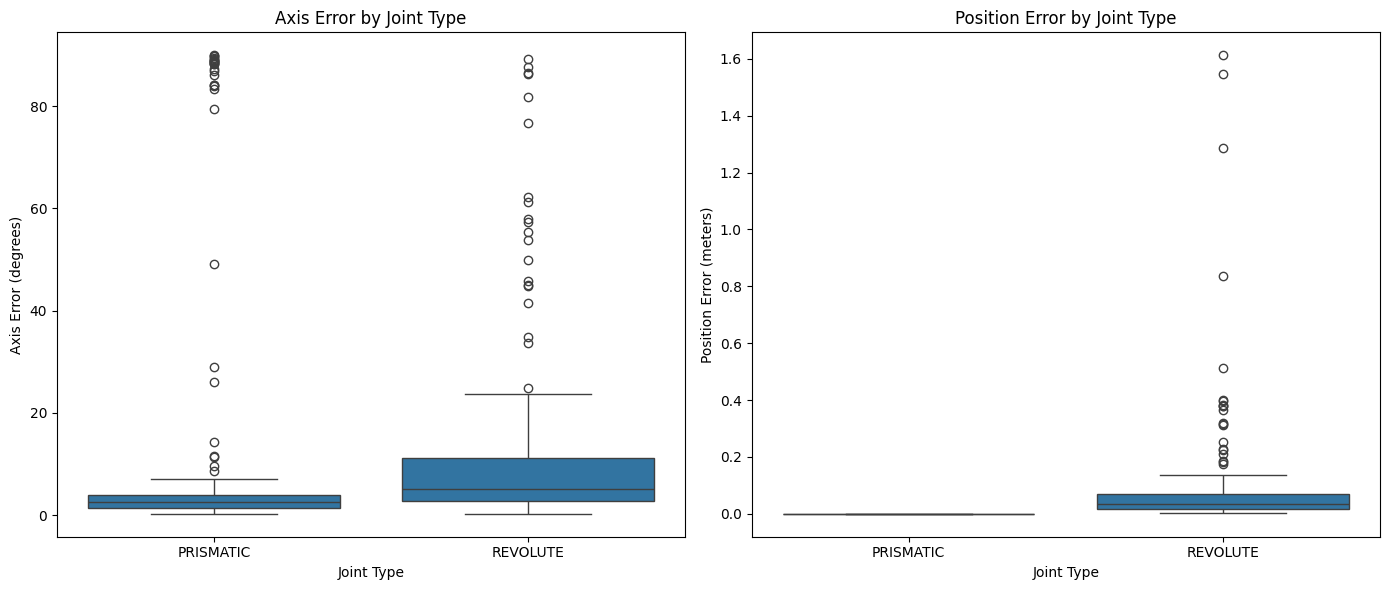

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame for better analysis
df_results = pd.DataFrame([{
    'gt_joint_type': seg['gt_joint_type'],
    'pred_joint_type': seg['pred_joint_type'],
    'axis_error_rad': seg['axis_error'],
    'axis_error_deg': np.degrees(seg['axis_error']),
    'position_error_m': seg['pos_error'],
    'tang_sim': seg['tang_sim'],
    'mode_acc': seg['mode_acc']
} for seg in all_segments])

print(f"Total segments evaluated: {len(df_results)}")

# Add a column for correct joint type classification
df_results['correct_type'] = df_results['gt_joint_type'].str.upper() == df_results['pred_joint_type'].str.upper()

# Failed estimates: position error > 2.5m (computed before filtering)
n_failed_pos = (df_results['position_error_m'] > 2.5).sum()
pct_failed_pos = 100.0 * n_failed_pos / len(df_results)

# Exclude failed estimates before computing means/medians
df_valid = df_results[df_results['position_error_m'] <= 2.5]

PERCENTILES = [50, 75, 90]

def make_percentile_fn(q):
    def percentile(x):
        return x.quantile(q / 100.0)
    percentile.__name__ = f'p{q}'
    return percentile

# Group by GT joint type and calculate metrics: mean, median, std, and percentiles.
# Data is heavily skewed, so percentiles are more informative than mean/std alone.
agg_kwargs = {'count': ('gt_joint_type', 'count')}
for metric, col in [('axis_error_deg', 'axis_error_deg'), ('position_error_m', 'position_error_m')]:
    agg_kwargs[f'avg_{metric}'] = (col, 'mean')
    agg_kwargs[f'median_{metric}'] = (col, 'median')
    agg_kwargs[f'std_{metric}'] = (col, 'std')
    for q in PERCENTILES:
        agg_kwargs[f'p{q}_{metric}'] = (col, make_percentile_fn(q))
agg_kwargs['type_accuracy'] = ('correct_type', 'mean')
agg_kwargs['tang_sim_avg'] = ('tang_sim', 'mean')
agg_kwargs['mode_acc_avg'] = ('mode_acc', 'mean')

joint_type_metrics = df_valid.groupby('gt_joint_type').agg(**agg_kwargs)

METRIC_COLUMNS = list(agg_kwargs.keys())

# Overall metrics (on filtered data)
overall_row = {'count': len(df_valid)}
for metric, col in [('axis_error_deg', 'axis_error_deg'), ('position_error_m', 'position_error_m')]:
    overall_row[f'avg_{metric}'] = df_valid[col].mean()
    overall_row[f'median_{metric}'] = df_valid[col].median()
    overall_row[f'std_{metric}'] = df_valid[col].std()
    for q in PERCENTILES:
        overall_row[f'p{q}_{metric}'] = df_valid[col].quantile(q / 100.0)
overall_row['type_accuracy'] = df_valid['correct_type'].mean()
overall_row['tang_sim_avg'] = df_valid['tang_sim'].mean() if 'tang_sim' in df_valid else None
overall_row['mode_acc_avg'] = df_valid['mode_acc'].mean() if 'mode_acc' in df_valid else None
overall = pd.DataFrame([overall_row], index=['OVERALL'])[METRIC_COLUMNS]

failed_pos_row = pd.DataFrame([{col: (n_failed_pos if col == 'count' else float('nan')) for col in METRIC_COLUMNS}],
                               index=[f'FAILED (pos_err > 2.5m)  {pct_failed_pos:.1f}%'])

# Combine and display
results_table = pd.concat([joint_type_metrics[METRIC_COLUMNS], overall, failed_pos_row])
results_table = results_table.round(3)
print("Articulation Estimation Results by Joint Type:")
display(results_table)

# Visualize the results
plt.figure(figsize=(14, 6))

# Axis error distribution by joint type
plt.subplot(1, 2, 1)
sns.boxplot(x='gt_joint_type', y='axis_error_deg', data=df_valid)
plt.title('Axis Error by Joint Type')
plt.xlabel('Joint Type') 
plt.ylabel('Axis Error (degrees)')

# Position error distribution by joint type
plt.subplot(1, 2, 2)
sns.boxplot(x='gt_joint_type', y='position_error_m', data=df_valid)
plt.title('Position Error by Joint Type')
plt.xlabel('Joint Type')
plt.ylabel('Position Error (meters)')

plt.tight_layout()
plt.show()

In [206]:
df_results

,gt_joint_type,pred_joint_type,axis_error_rad,axis_error_deg,position_error_m,tang_sim,mode_acc,correct_type
0,REVOLUTE,revolute,0.803090,46.013665,1.284009,0.433820,1.0,True
1,PRISMATIC,revolute,0.356025,20.398743,0.000000,0.937501,1.0,False
2,PRISMATIC,prismatic,1.524701,87.358914,0.000000,0.043647,1.0,True
3,PRISMATIC,revolute,0.457942,26.238164,0.000000,0.897171,0.0,False
4,REVOLUTE,prismatic,1.289271,73.869774,1.916989,0.766772,1.0,False
5,PRISMATIC,revolute,1.334478,76.459968,0.000000,0.234087,0.0,False
6,PRISMATIC,revolute,0.405895,23.256072,0.000000,0.918562,1.0,False
7,REVOLUTE,revolute,0.967058,55.408369,0.032310,0.070408,1.0,True
8,PRISMATIC,revolute,0.385963,22.114026,0.000000,0.926555,1.0,False
9,REVOLUTE,revolute,0.917375,52.561690,0.186052,0.158660,0.0,True
